# Torch spectral random-imagery model training

## Purpose

This notebook executes the 12 planned PyTorch spectral model variants on the fixed random-imagery reconstruction protocols and publishes 36 immutable Torch direction runs.

- **Cross-subject:** 141 train rows and 39 held-out rows with disjoint identities.
- **Identity-overlapping bidirectional cross-trial:** 81 train and 81 test rows in each direction.
- Every architecture/preprocessing pair trains one 36-logit multilabel model with final seeds 42, 43, and 44.
- Spectral imagery inputs are cropped before transformation and normalized with direction-train-only log-power z-score state.
- The summaries below validate training completeness. The protocol-separated comparison belongs to notebook 6.1.


## Reproducibility contract

All execution goes through `execute_torch_protocol`. `REUSE_EXISTING=True` trains when the complete immutable run set is absent and safely reuses it otherwise. The source random-imagery dataset is built once, while crop-spectral datasets are shared by preprocessing method.

In [1]:
from pathlib import Path
import gc
import os
import sys
import time

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-torch-spectral-models")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from experiments.random_imagery.shared import build_random_imagery_targets
from experiments.random_imagery_torch import (
    CropSpectralDataset,
    PRIMARY_TORCH_MODEL_IDS,
    execute_torch_protocol,
    load_torch_config,
)
from utils.datasets import NumpyDataset

MODEL_IDS = (
    "eegnet-fft-multilabel",
    "eegnet-morlet-multilabel",
    "eegnet-superlet-multilabel",
    "eegnet-stft-multilabel",
    "deep-convnet-fft-multilabel",
    "deep-convnet-morlet-multilabel",
    "deep-convnet-superlet-multilabel",
    "deep-convnet-stft-multilabel",
    "shallow-convnet-fft-multilabel",
    "shallow-convnet-morlet-multilabel",
    "shallow-convnet-superlet-multilabel",
    "shallow-convnet-stft-multilabel",
)
PROTOCOLS = ("cross-subject", "within-subject")
REUSE_EXISTING = True

assert MODEL_IDS == PRIMARY_TORCH_MODEL_IDS
pd.Series(
    {
        "cuda_available": torch.cuda.is_available(),
        "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "model_variants": len(MODEL_IDS),
        "protocols": ", ".join(PROTOCOLS),
        "reuse_existing": REUSE_EXISTING,
    },
    name="execution_context",
)


cuda_available                             True
cuda_device          NVIDIA GeForce RTX 3070 Ti
model_variants                               12
protocols         cross-subject, within-subject
reuse_existing                             True
Name: execution_context, dtype: object

In [2]:
configs = {model_id: load_torch_config(model_id) for model_id in MODEL_IDS}
reference_config = configs[MODEL_IDS[0]]
source_dataset = NumpyDataset(
    reference_config.dataset.dataset_dir,
    dataset_step_type=reference_config.dataset.recording_family,
    dataset_pattern_type=reference_config.dataset.pattern_type,
    cache_policy="disk",
)
targets = build_random_imagery_targets(
    source_dataset.samples,
    image_rows=reference_config.dataset.image_rows,
    image_columns=reference_config.dataset.image_columns,
)

for config in configs.values():
    assert config.dataset == reference_config.dataset
    assert config.spectral_input == reference_config.spectral_input
    assert config.split == reference_config.split

spectral_datasets = {
    method: CropSpectralDataset(
        source_dataset,
        method=method,
        preprocessing_config_overrides=reference_config.preprocessing_overrides,
        input_config=reference_config.spectral_input,
        cache_policy="disk",
    )
    for method in ("fft", "morlet", "superlet", "stft")
}

shape_rows = []
for method, dataset in spectral_datasets.items():
    sample = dataset[0]
    shape_rows.append(
        {
            "method": method,
            "config_hash": dataset.config_hash,
            "eeg_power_shape": tuple(sample.eeg_power.shape),
            "frequency_bins": int(sample.frequencies.size),
            "time_bins": None if sample.times is None else int(sample.times.size),
            "crop_bounds_seconds": sample.crop_bounds_seconds,
        }
    )

assert len(source_dataset) == 180
assert targets.y.shape == (180, 36)
assert len(np.unique(targets.subject_ids)) == 33
pd.DataFrame(shape_rows)


,method,config_hash,eeg_power_shape,frequency_bins,time_bins,crop_bounds_seconds
0,fft,ca87f68c0a61a0aa,"(63, 39)",39,NaN,"(0.5, 15.5)"
1,morlet,cd7e2d5669819de8,"(63, 39, 49)",39,49.0,"(0.5, 15.5)"
2,superlet,e4e75c01a81659bb,"(63, 39, 46)",39,46.0,"(0.5, 15.5)"
3,stft,c641b8a83b58dcf4,"(63, 39, 51)",39,51.0,"(0.5, 15.5)"


In [3]:
workflow_results = []
execution_rows = []

for model_index, model_id in enumerate(MODEL_IDS, start=1):
    config = configs[model_id]
    dataset = spectral_datasets[config.training.method]
    for protocol in PROTOCOLS:
        started = time.perf_counter()
        result = execute_torch_protocol(
            protocol,
            config=config,
            reuse_existing=REUSE_EXISTING,
            spectral_dataset=dataset,
            targets=targets,
        )
        elapsed = time.perf_counter() - started
        workflow_results.append(result)
        execution_rows.append(
            {
                "model_index": model_index,
                "model_id": model_id,
                "protocol": protocol,
                "method": config.training.method,
                "architecture": config.training.architecture,
                "reused": result.reused,
                "direction_runs": len(result.run_dirs),
                "elapsed_seconds": elapsed,
            }
        )
        print(
            f"[{model_index:02d}/{len(MODEL_IDS)}] {model_id} | {protocol} | "
            f"{'reused' if result.reused else 'trained'} | {len(result.run_dirs)} run(s) | "
            f"{elapsed:.1f}s",
            flush=True,
        )
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

execution_df = pd.DataFrame(execution_rows)
assert int(execution_df["direction_runs"].sum()) == 36
execution_df


[01/12] eegnet-fft-multilabel | cross-subject | trained | 1 run(s) | 21.1s


[01/12] eegnet-fft-multilabel | within-subject | trained | 2 run(s) | 26.4s


[02/12] eegnet-morlet-multilabel | cross-subject | trained | 1 run(s) | 52.8s


[02/12] eegnet-morlet-multilabel | within-subject | trained | 2 run(s) | 38.0s


[03/12] eegnet-superlet-multilabel | cross-subject | trained | 1 run(s) | 314.1s


...

[11/12] shallow-convnet-superlet-multilabel | cross-subject | trained | 1 run(s) | 34.5s


[11/12] shallow-convnet-superlet-multilabel | within-subject | trained | 2 run(s) | 55.4s


[12/12] shallow-convnet-stft-multilabel | cross-subject | trained | 1 run(s) | 41.9s


[12/12] shallow-convnet-stft-multilabel | within-subject | trained | 2 run(s) | 63.3s


,model_index,model_id,protocol,method,architecture,reused,direction_runs,elapsed_seconds
0,1,eegnet-fft-multilabel,cross-subject,fft,eegnet,False,1,21.133519
1,1,eegnet-fft-multilabel,within-subject,fft,eegnet,False,2,26.448928
2,2,eegnet-morlet-multilabel,cross-subject,morlet,eegnet,False,1,52.784435
3,2,eegnet-morlet-multilabel,within-subject,morlet,eegnet,False,2,38.029750
4,3,eegnet-superlet-multilabel,cross-subject,superlet,eegnet,False,1,314.115005
5,3,eegnet-superlet-multilabel,within-subject,superlet,eegnet,False,2,56.314769
6,4,eegnet-stft-multilabel,cross-subject,stft,eegnet,False,1,65.230232
7,4,eegnet-stft-multilabel,within-subject,stft,eegnet,False,2,110.686069
8,5,deep-convnet-fft-multilabel,cross-subject,fft,deep-convnet,False,1,20.187746
9,5,deep-convnet-fft-multilabel,within-subject,fft,deep-convnet,False,2,23.312041


In [4]:
second_reuse_rows = []
for model_id in MODEL_IDS:
    config = configs[model_id]
    dataset = spectral_datasets[config.training.method]
    for protocol in PROTOCOLS:
        result = execute_torch_protocol(
            protocol,
            config=config,
            reuse_existing=True,
            spectral_dataset=dataset,
            targets=targets,
        )
        second_reuse_rows.append(
            {
                "model_id": model_id,
                "protocol": protocol,
                "reused": result.reused,
                "direction_runs": len(result.run_dirs),
            }
        )

second_reuse_df = pd.DataFrame(second_reuse_rows)
assert second_reuse_df["reused"].all()
assert int(second_reuse_df["direction_runs"].sum()) == 36
print("SECOND_REUSE_VERIFIED")
second_reuse_df


SECOND_REUSE_VERIFIED


,model_id,protocol,reused,direction_runs
0,eegnet-fft-multilabel,cross-subject,True,1
1,eegnet-fft-multilabel,within-subject,True,2
2,eegnet-morlet-multilabel,cross-subject,True,1
3,eegnet-morlet-multilabel,within-subject,True,2
4,eegnet-superlet-multilabel,cross-subject,True,1
5,eegnet-superlet-multilabel,within-subject,True,2
6,eegnet-stft-multilabel,cross-subject,True,1
7,eegnet-stft-multilabel,within-subject,True,2
8,deep-convnet-fft-multilabel,cross-subject,True,1
9,deep-convnet-fft-multilabel,within-subject,True,2


In [5]:
run_rows = []
training_rows = []
leakage_rows = []
seed_rows = []
combined_rows = []

for result in workflow_results:
    if result.summary["combined"] is not None:
        combined = result.summary["combined"]
        combined_rows.append(
            {
                "model_id": combined["model_id"],
                "protocol": combined["protocol"],
                "n_test_rows": combined["n_test_rows"],
                "n_subjects": combined["n_subjects"],
                "mean_balanced_accuracy": combined["model_metrics"]["mean_balanced_accuracy"],
                "bootstrap_lower": combined["model_bootstrap"]["lower"],
                "bootstrap_upper": combined["model_bootstrap"]["upper"],
            }
        )
    for run in result.runs:
        metrics = run.evaluation["model_metrics"]
        bootstrap = run.evaluation["model_bootstrap"]
        split = run.evaluation["split"]
        audit = run.evaluation["split_audit"]
        run_rows.append(
            {
                "model_id": run.config.model_id,
                "architecture": run.config.training.architecture,
                "method": run.config.training.method,
                "protocol": run.evaluation["protocol"],
                "direction": run.evaluation["direction"]["name"],
                "n_train_rows": split["n_train_rows"],
                "n_test_rows": split["n_test_rows"],
                "mean_balanced_accuracy": metrics["mean_balanced_accuracy"],
                "bootstrap_lower": bootstrap["lower"],
                "bootstrap_upper": bootstrap["upper"],
                "mean_score_mse": metrics["mean_score_mse"],
                "micro_iou": metrics["micro_iou"],
                "hamming_loss": metrics["hamming_loss"],
                "exact_match_accuracy": metrics["exact_match_accuracy"],
                "run_dir": str(run.run_dir),
            }
        )
        training_rows.append(
            {
                "model_id": run.config.model_id,
                "protocol": run.evaluation["protocol"],
                "direction": run.evaluation["direction"]["name"],
                "parameter_count": run.training["parameter_count"],
                "selected_epoch_count": run.training["selected_epoch_count"],
                "member_epochs": tuple(item["epoch"] for item in run.training["ensemble_members"]),
                "training_seconds": run.training["training_seconds"],
                "prediction_seconds": run.training["prediction_seconds"],
                "torch_cuda_available": run.environment["torch_cuda_available"],
                "torch_cuda_device": run.environment["torch_cuda_device"],
            }
        )
        leakage_rows.append(
            {
                "model_id": run.config.model_id,
                "protocol": run.evaluation["protocol"],
                "direction": run.evaluation["direction"]["name"],
                "overlapping_subjects": len(audit["overlapping_subjects"]),
                "overlapping_sample_keys": len(audit["overlapping_sample_keys"]),
                "overlapping_seeds": len(audit["overlapping_seeds"]),
                "overlapping_image_fingerprints": len(audit["overlapping_image_fingerprints"]),
                "has_forbidden_leakage": audit["has_forbidden_leakage"],
                "subject_contract_satisfied": audit["subject_contract_satisfied"],
                "trial_contract_satisfied": audit["trial_contract_satisfied"],
            }
        )
        seed_means = run.member_scores.mean(axis=(1, 2))
        seed_rows.append(
            {
                "model_id": run.config.model_id,
                "protocol": run.evaluation["protocol"],
                "direction": run.evaluation["direction"]["name"],
                "member_score_mean_min": float(seed_means.min()),
                "member_score_mean_max": float(seed_means.max()),
                "member_score_mean_std": float(seed_means.std()),
            }
        )

runs_df = pd.DataFrame(run_rows)
training_df = pd.DataFrame(training_rows)
leakage_df = pd.DataFrame(leakage_rows)
seed_df = pd.DataFrame(seed_rows)
combined_df = pd.DataFrame(combined_rows)

assert len(runs_df) == 36
assert set(runs_df["protocol"]) == {"cross-subject", "within-subject"}
assert set(runs_df["method"]) == {"fft", "morlet", "superlet", "stft"}
assert not leakage_df["has_forbidden_leakage"].any()
assert set(runs_df.loc[runs_df["protocol"] == "cross-subject", "n_train_rows"]) == {141}
assert set(runs_df.loc[runs_df["protocol"] == "cross-subject", "n_test_rows"]) == {39}
assert set(runs_df.loc[runs_df["protocol"] == "within-subject", "n_train_rows"]) == {81}
assert set(runs_df.loc[runs_df["protocol"] == "within-subject", "n_test_rows"]) == {81}
print("TORCH_STAGE5_TRAINING_COMPLETE")
runs_df.sort_values(["protocol", "architecture", "method", "direction"]).reset_index(drop=True)


TORCH_STAGE5_TRAINING_COMPLETE


,model_id,architecture,method,protocol,direction,n_train_rows,n_test_rows,mean_balanced_accuracy,bootstrap_lower,bootstrap_upper,mean_score_mse,micro_iou,hamming_loss,exact_match_accuracy,run_dir
0,deep-convnet-fft-multilabel,deep-convnet,fft,cross-subject,cross-subject,141,39,0.486743,0.468129,0.505549,0.258808,0.334280,0.500712,0.0,artifacts/experiments/random-imagery-torch/dee...
1,deep-convnet-morlet-multilabel,deep-convnet,morlet,cross-subject,cross-subject,141,39,0.508782,0.483808,0.538586,0.250729,0.353832,0.486467,0.0,artifacts/experiments/random-imagery-torch/dee...
2,deep-convnet-stft-multilabel,deep-convnet,stft,cross-subject,cross-subject,141,39,0.509145,0.491834,0.525755,0.257238,0.352436,0.482906,0.0,artifacts/experiments/random-imagery-torch/dee...
3,deep-convnet-superlet-multilabel,deep-convnet,superlet,cross-subject,cross-subject,141,39,0.490313,0.475735,0.510280,0.254749,0.340000,0.493590,0.0,artifacts/experiments/random-imagery-torch/dee...
4,eegnet-fft-multilabel,eegnet,fft,cross-subject,cross-subject,141,39,0.508186,0.480997,0.538359,0.249993,0.349813,0.496439,0.0,artifacts/experiments/random-imagery-torch/eeg...
5,eegnet-morlet-multilabel,eegnet,morlet,cross-subject,cross-subject,141,39,0.496722,0.476967,0.520246,0.249981,0.312500,0.509259,0.0,artifacts/experiments/random-imagery-torch/eeg...
6,eegnet-stft-multilabel,eegnet,stft,cross-subject,cross-subject,141,39,0.500713,0.472926,0.526854,0.250208,0.317522,0.502137,0.0,artifacts/experiments/random-imagery-torch/eeg...
7,eegnet-superlet-multilabel,eegnet,superlet,cross-subject,cross-subject,141,39,0.497561,0.482478,0.515894,0.249902,0.273105,0.498575,0.0,artifacts/experiments/random-imagery-torch/eeg...
8,shallow-convnet-fft-multilabel,shallow-convnet,fft,cross-subject,cross-subject,141,39,0.505675,0.471549,0.534897,0.251356,0.346629,0.490028,0.0,artifacts/experiments/random-imagery-torch/sha...
9,shallow-convnet-morlet-multilabel,shallow-convnet,morlet,cross-subject,cross-subject,141,39,0.513443,0.488845,0.536044,0.251392,0.330321,0.475071,0.0,artifacts/experiments/random-imagery-torch/sha...


In [6]:
summary_by_protocol = (
    runs_df.groupby(["protocol", "architecture", "method"], as_index=False)
    .agg(
        direction_runs=("direction", "count"),
        mean_balanced_accuracy=("mean_balanced_accuracy", "mean"),
        min_balanced_accuracy=("mean_balanced_accuracy", "min"),
        max_balanced_accuracy=("mean_balanced_accuracy", "max"),
        mean_hamming_loss=("hamming_loss", "mean"),
        mean_score_mse=("mean_score_mse", "mean"),
    )
    .sort_values(["protocol", "mean_balanced_accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)
summary_by_protocol


,protocol,architecture,method,direction_runs,mean_balanced_accuracy,min_balanced_accuracy,max_balanced_accuracy,mean_hamming_loss,mean_score_mse
0,cross-subject,shallow-convnet,morlet,1,0.513443,0.513443,0.513443,0.475071,0.251392
1,cross-subject,deep-convnet,stft,1,0.509145,0.509145,0.509145,0.482906,0.257238
2,cross-subject,deep-convnet,morlet,1,0.508782,0.508782,0.508782,0.486467,0.250729
3,cross-subject,eegnet,fft,1,0.508186,0.508186,0.508186,0.496439,0.249993
4,cross-subject,shallow-convnet,fft,1,0.505675,0.505675,0.505675,0.490028,0.251356
5,cross-subject,eegnet,stft,1,0.500713,0.500713,0.500713,0.502137,0.250208
6,cross-subject,shallow-convnet,stft,1,0.498006,0.498006,0.498006,0.495726,0.251784
7,cross-subject,eegnet,superlet,1,0.497561,0.497561,0.497561,0.498575,0.249902
8,cross-subject,eegnet,morlet,1,0.496722,0.496722,0.496722,0.509259,0.249981
9,cross-subject,deep-convnet,superlet,1,0.490313,0.490313,0.490313,0.493590,0.254749


In [7]:
display(training_df.sort_values(["protocol", "model_id", "direction"]).reset_index(drop=True))
display(seed_df.sort_values(["protocol", "model_id", "direction"]).reset_index(drop=True))
display(leakage_df.sort_values(["protocol", "model_id", "direction"]).reset_index(drop=True))
display(combined_df.sort_values("mean_balanced_accuracy", ascending=False).reset_index(drop=True))


,model_id,protocol,direction,parameter_count,selected_epoch_count,member_epochs,training_seconds,prediction_seconds,torch_cuda_available,torch_cuda_device
0,deep-convnet-fft-multilabel,cross-subject,cross-subject,179890,24,"(24, 24, 24)",19.880416,0.077763,True,NVIDIA GeForce RTX 3070 Ti
1,deep-convnet-morlet-multilabel,cross-subject,cross-subject,184640,4,"(4, 4, 4)",28.303760,0.150433,True,NVIDIA GeForce RTX 3070 Ti
2,deep-convnet-stft-multilabel,cross-subject,cross-subject,184640,13,"(13, 13, 13)",38.559223,0.157390,True,NVIDIA GeForce RTX 3070 Ti
3,deep-convnet-superlet-multilabel,cross-subject,cross-subject,184640,13,"(13, 13, 13)",33.843457,0.137494,True,NVIDIA GeForce RTX 3070 Ti
4,eegnet-fft-multilabel,cross-subject,cross-subject,2495,4,"(4, 4, 4)",18.932088,1.994180,True,NVIDIA GeForce RTX 3070 Ti
5,eegnet-morlet-multilabel,cross-subject,cross-subject,17519,6,"(6, 6, 6)",47.159328,5.402182,True,NVIDIA GeForce RTX 3070 Ti
6,eegnet-stft-multilabel,cross-subject,cross-subject,18143,27,"(27, 27, 27)",64.072511,0.930302,True,NVIDIA GeForce RTX 3070 Ti
7,eegnet-superlet-multilabel,cross-subject,cross-subject,16567,3,"(3, 3, 3)",249.827370,64.049720,True,NVIDIA GeForce RTX 3070 Ti
8,shallow-convnet-fft-multilabel,cross-subject,cross-subject,102997,27,"(27, 27, 27)",21.067428,0.057859,True,NVIDIA GeForce RTX 3070 Ti
9,shallow-convnet-morlet-multilabel,cross-subject,cross-subject,122757,1,"(1, 1, 1)",20.189161,0.136271,True,NVIDIA GeForce RTX 3070 Ti


,model_id,protocol,direction,member_score_mean_min,member_score_mean_max,member_score_mean_std
0,deep-convnet-fft-multilabel,cross-subject,cross-subject,0.500916,0.515236,0.006091
1,deep-convnet-morlet-multilabel,cross-subject,cross-subject,0.498802,0.506117,0.002992
2,deep-convnet-stft-multilabel,cross-subject,cross-subject,0.501864,0.512571,0.004774
3,deep-convnet-superlet-multilabel,cross-subject,cross-subject,0.494044,0.512174,0.007484
4,eegnet-fft-multilabel,cross-subject,cross-subject,0.499761,0.500520,0.000346
5,eegnet-morlet-multilabel,cross-subject,cross-subject,0.499263,0.500387,0.000466
6,eegnet-stft-multilabel,cross-subject,cross-subject,0.498021,0.499939,0.000810
7,eegnet-superlet-multilabel,cross-subject,cross-subject,0.498902,0.499271,0.000164
8,shallow-convnet-fft-multilabel,cross-subject,cross-subject,0.498160,0.503623,0.002243
9,shallow-convnet-morlet-multilabel,cross-subject,cross-subject,0.493280,0.499846,0.002706


,model_id,protocol,direction,overlapping_subjects,overlapping_sample_keys,overlapping_seeds,overlapping_image_fingerprints,has_forbidden_leakage,subject_contract_satisfied,trial_contract_satisfied
0,deep-convnet-fft-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True
1,deep-convnet-morlet-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True
2,deep-convnet-stft-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True
3,deep-convnet-superlet-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True
4,eegnet-fft-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True
5,eegnet-morlet-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True
6,eegnet-stft-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True
7,eegnet-superlet-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True
8,shallow-convnet-fft-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True
9,shallow-convnet-morlet-multilabel,cross-subject,cross-subject,0,0,0,0,False,True,True


,model_id,protocol,n_test_rows,n_subjects,mean_balanced_accuracy,bootstrap_lower,bootstrap_upper
0,deep-convnet-stft-multilabel,within-subject,162,27,0.512011,0.500668,0.520872
1,eegnet-stft-multilabel,within-subject,162,27,0.510924,0.498673,0.520471
2,deep-convnet-superlet-multilabel,within-subject,162,27,0.506225,0.491947,0.517677
3,deep-convnet-fft-multilabel,within-subject,162,27,0.502737,0.490701,0.513439
4,deep-convnet-morlet-multilabel,within-subject,162,27,0.500067,0.487988,0.509487
5,shallow-convnet-superlet-multilabel,within-subject,162,27,0.499370,0.485162,0.510761
6,eegnet-fft-multilabel,within-subject,162,27,0.499251,0.488162,0.508790
7,eegnet-superlet-multilabel,within-subject,162,27,0.499157,0.487246,0.509692
8,eegnet-morlet-multilabel,within-subject,162,27,0.497006,0.485720,0.507204
9,shallow-convnet-morlet-multilabel,within-subject,162,27,0.496206,0.481365,0.507418


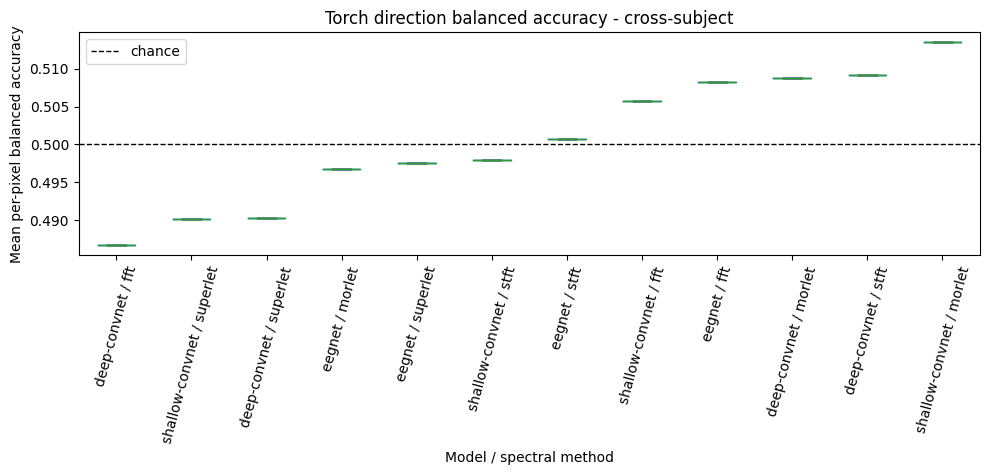

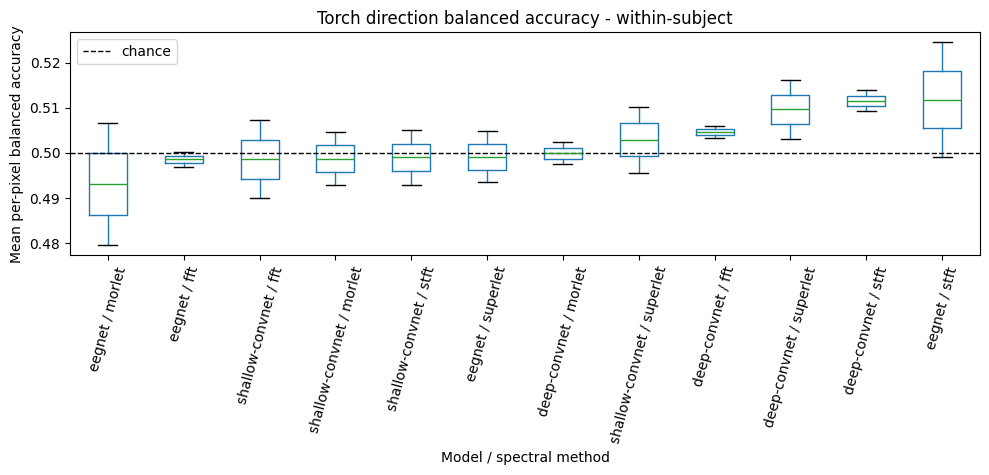

In [8]:
plot_df = runs_df.copy()
plot_df["variant"] = plot_df["architecture"] + " / " + plot_df["method"]
for protocol, protocol_df in plot_df.groupby("protocol", sort=True):
    ordered = (
        protocol_df.groupby("variant")["mean_balanced_accuracy"]
        .mean()
        .sort_values()
        .index
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    protocol_df.assign(variant=pd.Categorical(protocol_df["variant"], ordered, ordered=True)).boxplot(
        column="mean_balanced_accuracy",
        by="variant",
        ax=ax,
        rot=75,
        grid=False,
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance")
    ax.set_title(f"Torch direction balanced accuracy - {protocol}")
    ax.set_xlabel("Model / spectral method")
    ax.set_ylabel("Mean per-pixel balanced accuracy")
    ax.legend(loc="best")
    fig.suptitle("")
    fig.tight_layout()
    plt.show()
